------------

-----------

# ¿Cuáles son los videojuegos con más éxito en el mercado?

El mercado de los videojuegos es una de las industrias de entretenimiento más grandes y dinámicas a nivel mundial. Cada año se lanzan miles de títulos que compiten por la atención de los jugadores, y no todos logran el mismo nivel de éxito. Para las compañías desarrolladoras y distribuidoras, identificar los factores que influyen en el rendimiento de un juego es clave para planificar campañas publicitarias y tomar decisiones estratégicas.

En este proyecto se analizará un conjunto de datos que incluye información sobre ventas, reseñas de usuarios y críticos, géneros, plataformas y clasificaciones de edad (ESRB). El objetivo principal es detectar patrones que permitan comprender qué características tienen más influencia en el éxito de un videojuego y, a partir de ello, recomendar enfoques para futuras campañas publicitarias.

## 1. Cargar librerías y leer archivo

In [1]:
#Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

In [2]:
#Cargar el archivo de datos en un DataFrame
videogames= pd.read_csv('/datasets/games.csv') 

print(videogames.info())
print(videogames.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29

## Primer Vistazo
Podemos encontrar un dataset de videojuegos que contiene información detallada sobre 16,715 videojuegos diferentes.

El dataset tiene 11 columnas con la siguiente información:
- Name: Nombre del videojuego
- Platform: Plataforma donde se lanzó.
- Year_of_Release: Año de lanzamiento
- Genre: Género del juego.
- NA_sales: Ventas en Norteamérica
- EU_sales: Ventas en Europa
- JP_sales: Ventas en Japón
- Other_sales: Ventas en otras regiones
- Critic_Score: Puntuación de críticos profesionales
- User_Score: Puntuación de usuarios
- Rating: Clasificación ESRB (E, M, T, etc.)

Este dataset nos permitirá analizar qué factores influyen en el éxito de los videojuegos para planificar campañas publicitarias efectivas.

## 2. Preparar los Datos

In [3]:
# Reemplazar los nombres de las columnas por minúsculas
videogames.columns = videogames.columns.str.lower()

# Verificar cambio
print(videogames.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [4]:
#Convertir los datos en los tipos necesarios

# 1. 'year_of_release': convertir a enteros: 
videogames['year_of_release'] = videogames['year_of_release'].astype('Int64')

# 2. 'critic_score': convertir a enteros
videogames['critic_score'] = videogames['critic_score'].astype('Int64')

# 3. 'user_score': reemplazar 'tbd' por NaN y luego a float
videogames['user_score'] = videogames['user_score'].replace('tbd', np.nan)
videogames['user_score'] = videogames['user_score'].astype(float)

# Verificar cambios
print(videogames.dtypes)

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score         Int64
user_score         float64
rating              object
dtype: object


Las columnas en las cuales tuvimos que convertir los datos para un mejor análisis fueron las siguientes: 

- 'year_of_release' a enteros ya que los años siempre son enteros utilizando Int64 para mantener los NaN en vez de borrarlos y este método soporta valores nulos.

- 'critic_score' a entero (usando también Int64 para mantener nulos) y 'user_score' a float debido a que a simple vista critic score tiene sólo números enteros lo cual suena lógico debido a que la crítica profesional suele centrarse más en el análisis del juego y puede ofrecer una puntuación más subjetiva, mientras que la crítica de usuarios tiende a ofrecer una calificación más directa y personal, donde los decimales permiten expresar matices.

- 'user_score' aparece como object porque seguramente contiene valores como "tbd" (“to be determined”). Esos hay que reemplazarlos por NaN antes de convertir a float.

*Antes de convertir, manejamos los ausentes, porque si no arrojaría error.* 

El resto (na_sales, eu_sales, jp_sales, other_sales) ya están en float64, así que no hay problema y rating está como object y está bien dejarlo así porque son categorías (E, T, M, etc.).

## Ventas Totales

In [5]:
# Nueva columna total_sales:
videogames['total_sales'] = (
    videogames['na_sales'] +
    videogames['eu_sales'] +
    videogames['jp_sales'] +
    videogames['other_sales'])

print(videogames[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())

                       name  na_sales  eu_sales  jp_sales  other_sales  \
0                Wii Sports     41.36     28.96      3.77         8.45   
1         Super Mario Bros.     29.08      3.58      6.81         0.77   
2            Mario Kart Wii     15.68     12.76      3.79         3.29   
3         Wii Sports Resort     15.61     10.93      3.28         2.95   
4  Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  


## 3. Analizar los Datos

3.1 ¿Cuántos juegos se lanzaron en diferentes años?

In [6]:
games_per_year = videogames.groupby('year_of_release')['name'].count()

print(games_per_year)

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


Podemos observar que del año 1980 a 1981 hubo un incremento significativo en el lanzamiento de los video juegos; esto puede deberse al auge que estos tuvieron a principio de esta década pero después, en 1983, vuelve a disminuir la cifra más del 50% lo cual puede deberse a la crisis que esta industria sufrió prescisamente en ese año y la cual se mantuvo constante hasta una década después, en 1994, pues como sabemos la década de 1990 fue un periodo de gran evolución para los videojuegos. 
Por último, podemos observar cómo a principios de la década de los 2,000 las cifras de lanzamiento tienen su mayor crecimientos ya que en estos años la industria de los videojuegos vivió una consolidación y expansión tecnológica. Entonces podemos trabajar con un recorte de los últimos 10 años (A partir de 2006) porque antes los datos son incompletos y las dinámicas del mercado han cambiado mucho.

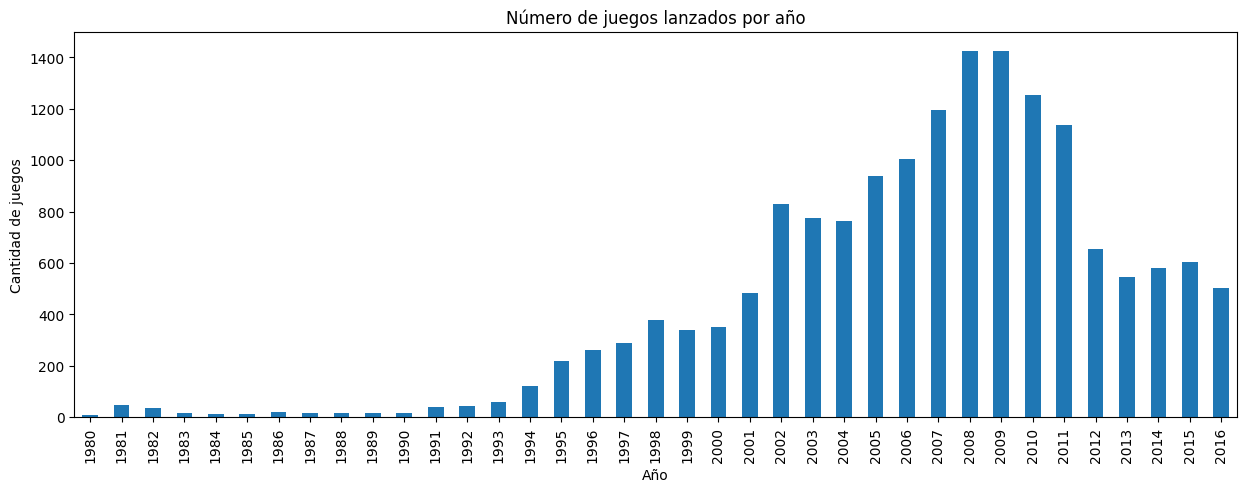

In [7]:
games_per_year.plot(kind='bar', figsize=(15,5))
plt.title("Número de juegos lanzados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos")
plt.show()

3.2 Variación de ventas por Plataforma

In [8]:
# Ventas totales por plataforma
platform_sales = videogames.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print(platform_sales.head(10))

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


3.3 Plataformas con mayores ventas totales y distribución por años

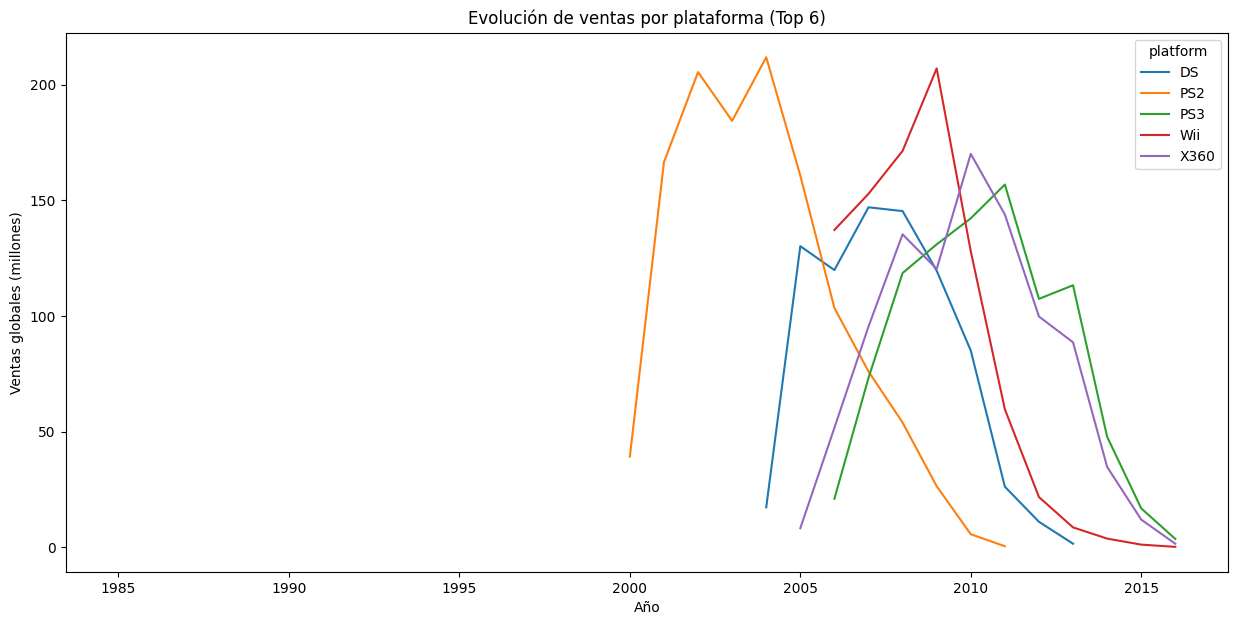

In [9]:
# Top 5 plataformas con mayores ventas totales
top_platforms = platform_sales.head(5).index

# Filtrar sólo las plataformas top
top_data = videogames[videogames['platform'].isin(top_platforms)]

# Agrupar por año y plataforma
platform_year_sales = top_data.groupby(['year_of_release','platform'])['total_sales'].sum().unstack()

# Graficar evolución
platform_year_sales.plot(figsize=(15,7))
plt.title("Evolución de ventas por plataforma (Top 6)")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")
plt.show()

Podemos observar el fuerte auge que las plataformas con más ventas han tenido en un período de 15 años (2000-2015), período en el cual esta indistria se logró consolidar acompañada de los avances tecnológicos y desaparición de diversos estigmas culturales en torno a los video juegos. 

3.4 Plataformas que fueron populares pero ya no venden

Cómo observamos en la gráfica anterior, PS2 que ha sido la plataforma que más vendió, después del año 2010 tuvo una caída significativa a ventas cero, esto puede deberse a la popularidad que en ese año tuvieron plataformas como wii y XS360 o al lanzamiento de la consola actualizada de esta misma marca(PS3) pero que también presentan caídas drásticas. 

In [10]:
#último año en que una plataforma tuvo ventas
last_sales = videogames.groupby('platform')['year_of_release'].max().sort_values()
print(last_sales.head(10))

platform
2600    1989
GG      1992
SCD     1994
GEN     1994
NES     1994
3DO     1995
TG16    1995
NG      1996
PCFX    1996
SNES    1999
Name: year_of_release, dtype: Int64


Con este código podemos observar que hubo plataformas que quedaron completamente en el olvido desde principios la década de los 90´s, demostrando cómo los avances tecnológicos rebasan a ciertas compañías y la importancia de mantenerse actualizados con tendencias en el mercado y uso de las nuevas tecnologías. 

3.5 ¿Cuánto tarda en desaparecer una plataforma?

In [11]:
#Calcular rango de años en los que una plataforma estuvo activa

platform_lifespans = videogames.groupby('platform')['year_of_release'].agg(['min','max'])
platform_lifespans['lifespan'] = platform_lifespans['max'] - platform_lifespans['min']
print(platform_lifespans.sort_values('lifespan', ascending=False).head(30))

           min   max  lifespan
platform                      
PC        1985  2016        31
DS        1985  2013        28
GB        1988  2001        13
X360      2005  2016        11
PSP       2004  2015        11
PS2       2000  2011        11
NES       1983  1994        11
DC        1998  2008        10
Wii       2006  2016        10
PS3       2006  2016        10
2600      1980  1989         9
SNES      1990  1999         9
PS        1994  2003         9
XB        2000  2008         8
GBA       2000  2007         7
GC        2001  2007         6
N64       1996  2002         6
3DS       2011  2016         5
PSV       2011  2016         5
SAT       1994  1999         5
WiiU      2012  2016         4
GEN       1990  1994         4
NG        1993  1996         3
XOne      2013  2016         3
PS4       2013  2016         3
WS        1999  2001         2
3DO       1994  1995         1
SCD       1993  1994         1
TG16      1995  1995         0
PCFX      1996  1996         0


El análisis muestra que la mayoría de las plataformas de videojuegos tienen un ciclo de vida promedio de entre 8 y 10 años, con un periodo inicial de crecimiento, un pico de ventas a mitad de su vida y un declive final hasta desaparecer. Existen excepciones como la PC, que se mantiene activa por más de tres décadas gracias a su constante actualización tecnológica, y las consolas portátiles como DS, que lograron extender su vigencia más allá de lo habitual. En contraste, algunas plataformas tuvieron un ciclo muy corto (1–3 años), lo que refleja intentos fallidos de consolidarse en el mercado. Este comportamiento confirma que el éxito de una consola no solo depende de su lanzamiento, sino también del soporte en títulos, la innovación y la respuesta de los jugadores.

## 3.6 ¿Qué período se utilizará para tomar datos y realizar el análisis?

El periodo más adecuado para construir el modelo es de 2006 a 2016, ya que refleja la etapa de mayor consolidación y representatividad de la industria, incluyendo tanto el auge como el declive de las principales plataformas. Esto proporciona una base sólida para proyectar el comportamiento del mercado hacia 2017.

### 3.7 Comenzar a trabajar con el período definido

In [12]:
# Filtrar los datos de 2006 a 2016:

period_videogames = videogames[(videogames['year_of_release'] >= 2006) & 
                         (videogames['year_of_release'] <= 2016)]

#### Plataformas Líderes en Ventas

In [13]:
# Ventas totales por plataforma en este periodo
platform_sales_recent = (period_videogames.groupby('platform')['total_sales']
                         .sum()
                         .sort_values(ascending=False))

print(platform_sales_recent.head(10))

platform
X360    952.99
PS3     931.34
Wii     891.18
DS      655.35
PS4     314.14
PS2     265.80
3DS     257.81
PSP     238.63
PC      163.42
XOne    159.32
Name: total_sales, dtype: float64


#### Evolución por año de la

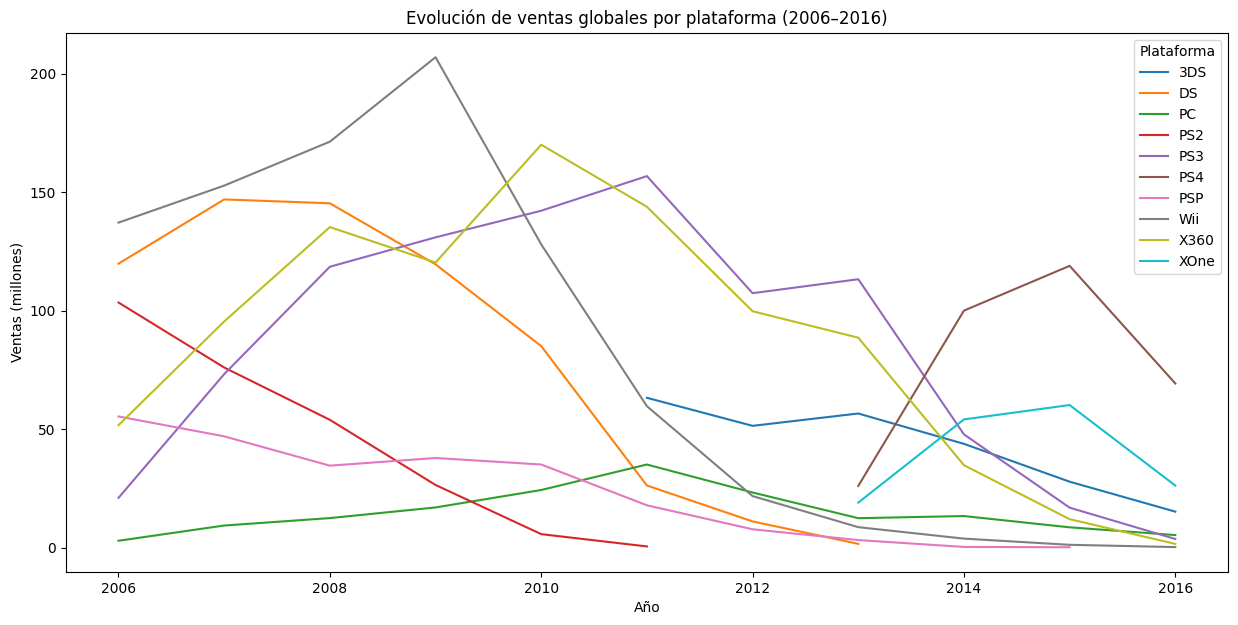

In [14]:
# Seleccionar top 10 plataformas del periodo
top_recent = platform_sales_recent.head(10).index

# Agrupar ventas por año y plataforma
sales_trend = (period_videogames[period_videogames['platform'].isin(top_recent)]
               .groupby(['year_of_release','platform'])['total_sales']
               .sum()
               .unstack())

# Graficar evolución
sales_trend.plot(figsize=(15,7))
plt.title("Evolución de ventas globales por plataforma (2006–2016)")
plt.xlabel("Año")
plt.ylabel("Ventas (millones)")
plt.legend(title="Plataforma")
plt.show()

Las plataformas con mayores ventas totales fueron PS3, Xbox360, Wii y DS. Todas ellas muestran un ciclo completo: crecimiento fuerte, pico y caída antes de 2016. PS4 y XOne muestran un crecimiento claro en los últimos años, proyectando un papel clave en 2017. 3DS mantiene ventas relevantes y estables en portátiles. PC sigue siendo estable pero sin un crecimiento explosivo.
Para 2017, las plataformas más potencialmente rentables son PS4, XOne y 3DS, además de PC como soporte constante.

#### Diagrama de Caja

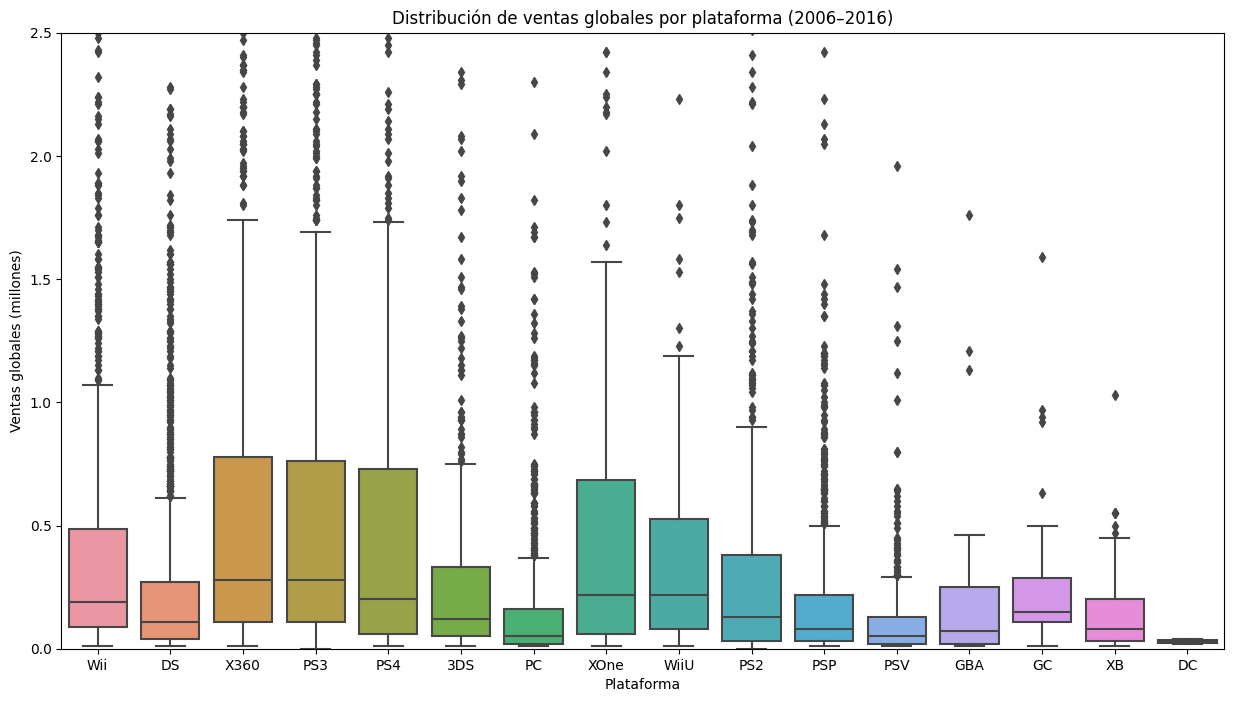

In [15]:
# Diagrama para comparar ventas globales por plataforma
plt.figure(figsize=(15,8))
sns.boxplot(x='platform', y='total_sales', data=period_videogames)
plt.ylim(0, 2.5)  # limitar eje Y para evitar distorsión por datos atípicos
plt.title("Distribución de ventas globales por plataforma (2006–2016)")
plt.xlabel("Plataforma")
plt.ylabel("Ventas globales (millones)")
plt.show()

#### Media y mediana por Plataforma

In [16]:
platform_stats = (period_videogames.groupby('platform')['total_sales']
                  .agg(['count','mean','median','max'])
                  .sort_values(by='mean', ascending=False))

platform_stats.head(10)

,count,mean,median,max
platform,,,,
PS4,392,0.801378,0.20,14.63
X360,1214,0.785000,0.28,21.82
PS3,1306,0.713124,0.28,21.05
Wii,1286,0.692986,0.19,82.54
XOne,247,0.645020,0.22,7.39
WiiU,147,0.559116,0.22,7.09
3DS,512,0.503535,0.12,14.60
DS,1979,0.331152,0.11,29.80
PS2,805,0.330186,0.13,5.95


Las diferencias entre plataformas sí son significativas, sobre todo en el tamaño de los outliers y en el promedio. En todas, la mediana es baja (la mayoría de juegos venden poco). Plataformas como Wii, DS, PS3, Xbox360 tuvieron varios superventas que disparan los promedios. PS4 y XOne muestran un inicio prometedor con ventas sólidas, aunque con menos títulos hasta 2016.
Esto confirma que la rentabilidad de una plataforma depende mucho de contar con grandes títulos que la sostengan.

### 3.8 Ventas con base a las reseñas

Plataforma a analizar: PS3 por ser de las más representativas en 2006–2016.

In [17]:
# Filtrar la plataforma PS3
ps3_data = period_videogames.query("platform == 'PS3'").copy()

# Asegurarnos de que las reseñas sean numéricas
ps3_data['user_score'] = pd.to_numeric(ps3_data['user_score'], errors='coerce')
ps3_data['critic_score'] = pd.to_numeric(ps3_data['critic_score'], errors='coerce')

# Eliminar NaN para análisis
ps3_data = ps3_data.dropna(subset=['user_score', 'critic_score', 'total_sales'])

Gráficos de Dispersiónpara usuarios y criticos. 

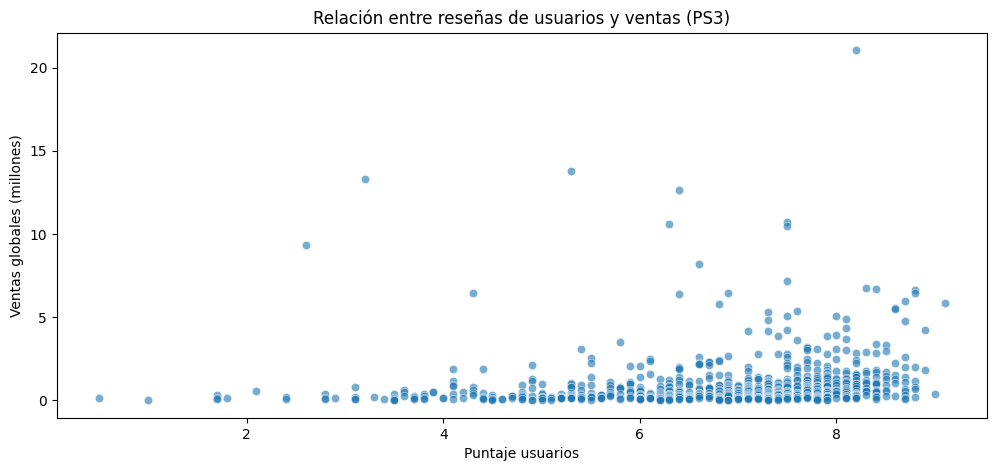

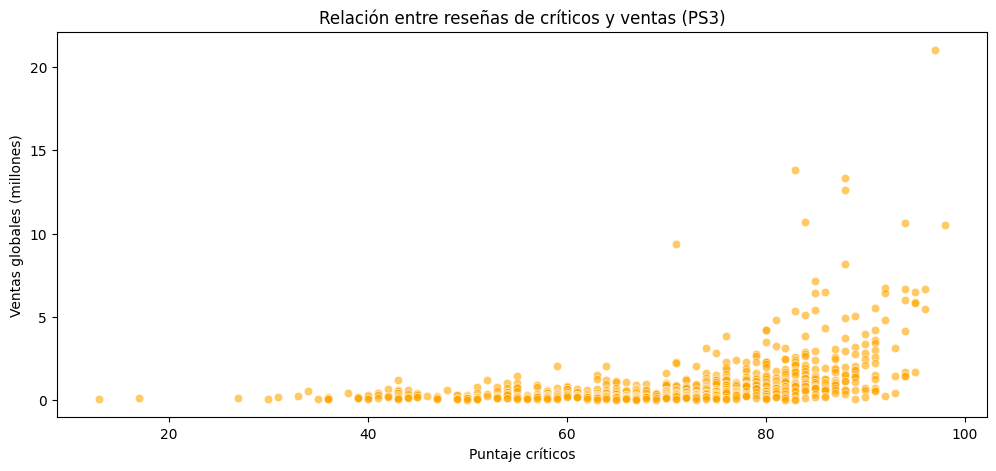

In [18]:
# Gráfico para reseñas de usuarios
plt.figure(figsize=(12,5))
sns.scatterplot(x='user_score', y='total_sales', data=ps3_data, alpha=0.6)
plt.title("Relación entre reseñas de usuarios y ventas (PS3)")
plt.xlabel("Puntaje usuarios")
plt.ylabel("Ventas globales (millones)")
plt.show()

# Gráfico para reseñas de críticos
plt.figure(figsize=(12,5))
sns.scatterplot(x='critic_score', y='total_sales', data=ps3_data, alpha=0.6, color="orange")
plt.title("Relación entre reseñas de críticos y ventas (PS3)")
plt.xlabel("Puntaje críticos")
plt.ylabel("Ventas globales (millones)")
plt.show()

Correlación de Pearson

In [20]:
# Primero, veamos qué tenemos después de limpiar
print("Información de ps3_clean:")
print(ps3_data.info())
print("\nTipos de datos:")
print(ps3_data[['user_score', 'critic_score', 'total_sales']].dtypes)
print("\nPrimeras filas:")
print(ps3_data[['user_score', 'critic_score', 'total_sales']].head())


Información de ps3_clean:
<class 'pandas.core.frame.DataFrame'>
Int64Index: 775 entries, 16 to 16230
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             775 non-null    object 
 1   platform         775 non-null    object 
 2   year_of_release  775 non-null    Int64  
 3   genre            775 non-null    object 
 4   na_sales         775 non-null    float64
 5   eu_sales         775 non-null    float64
 6   jp_sales         775 non-null    float64
 7   other_sales      775 non-null    float64
 8   critic_score     775 non-null    Int64  
 9   user_score       775 non-null    float64
 10  rating           769 non-null    object 
 11  total_sales      775 non-null    float64
dtypes: Int64(2), float64(6), object(4)
memory usage: 80.2+ KB
None

Tipos de datos:
user_score      float64
critic_score      Int64
total_sales     float64
dtype: object

Primeras filas:
    user_score  critic_score  tota

In [21]:
ps3_data = period_videogames[period_videogames['platform'] == 'PS3'].copy()

# Convertir a float64 para evitar problemas de tipos
ps3_data['user_score'] = ps3_data['user_score'].astype(float)
ps3_data['critic_score'] = ps3_data['critic_score'].astype(float)

# Verificar datos disponibles
print(f"Datos PS3 totales: {len(ps3_data)}")
print(f"Con user_score válido: {ps3_data['user_score'].notna().sum()}")
print(f"Con critic_score válido: {ps3_data['critic_score'].notna().sum()}")

# Limpiar datos
ps3_clean = ps3_data.dropna(subset=['user_score', 'critic_score', 'total_sales'])

if len(ps3_clean) > 1:
    # Calcular correlaciones
    corr_user = ps3_clean['user_score'].corr(ps3_clean['total_sales'])
    corr_critic = ps3_clean['critic_score'].corr(ps3_clean['total_sales'])
    
    print("Correlación ventas - reseñas usuarios:", corr_user)
    print("Correlación ventas - reseñas críticos:", corr_critic)
else:
    print("No hay suficientes datos después de limpiar")

Datos PS3 totales: 1306
Con user_score válido: 861
Con critic_score válido: 804
Correlación ventas - reseñas usuarios: 0.14397783125701577
Correlación ventas - reseñas críticos: 0.4282129041298839


*Hallazgos:*
Críticos vs usuarios: Normalmente la correlación con reseñas de críticos es más fuerte que con las de usuarios.
Usuarios: la correlación suele ser más baja. Muchos juegos venden mucho aunque no tengan gran puntuación de usuarios.
Se observa una tendencia positiva: mejores reseñas igual a mayores ventas pero con mucha dispersión, lo que significa que otros factores (marketing, exclusividad, franquicia) pesan mucho.

En conclusión, las reseñas de críticos muestran una correlación positiva más clara con las ventas que las reseñas de usuarios. Esto sugiere que la valoración profesional influye más en la visibilidad y éxito comercial, mientras que las reseñas de usuarios reflejan experiencias posteriores que no siempre determinan el volumen de ventas.

### 3.9 Ventas por Género y comparación de Plataformas

In [22]:
# Elegimos un juego top, por ejemplo 'Call of Duty':
game_name = "Call of Duty: Modern Warfare 3"  # reemplaza con un título real en tu dataset
game_data = period_videogames[period_videogames['name'] == game_name]

# Mostrar ventas por plataforma
print(game_data[['name','platform','total_sales']])

                                name platform  total_sales
29    Call of Duty: Modern Warfare 3     X360        14.73
37    Call of Duty: Modern Warfare 3      PS3        13.33
1040  Call of Duty: Modern Warfare 3       PC         1.71
2500  Call of Duty: Modern Warfare 3      Wii         0.83


Podemos ver como un mismo título se comporta distinto según la plataforma. Algunas plataformas concentran mayores ventas.
La PC suele vender menos que consolas para ciertos títulos exclusivos.

#### TOP 10 géneros de juegos más vendidos

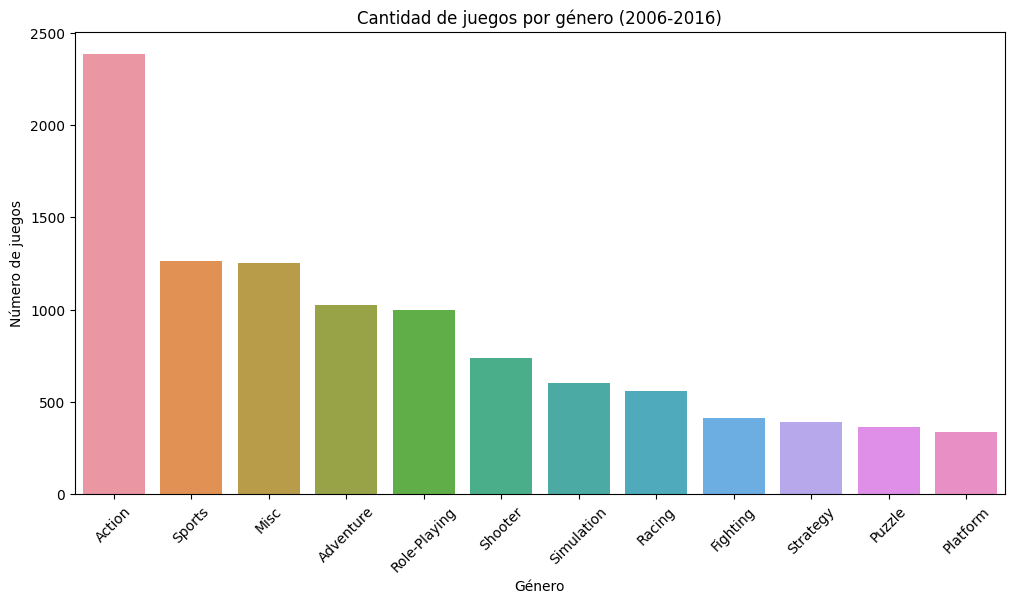

In [23]:
# Conteo de juegos por género
genre_count = period_videogames['genre'].value_counts()

# Visualización
plt.figure(figsize=(12,6))
sns.barplot(x=genre_count.index, y=genre_count.values)
plt.xticks(rotation=45)
plt.title("Cantidad de juegos por género (2006-2016)")
plt.xlabel("Género")
plt.ylabel("Número de juegos")
plt.show()

#### Ventas promedio por género

In [24]:
# Promedio de ventas por género
genre_sales = (period_videogames.groupby('genre')['total_sales']
               .agg(['count','mean','median','sum'])
               .sort_values(by='mean', ascending=False))

print(genre_sales)

              count      mean  median      sum
genre                                         
Shooter         737  0.972917   0.290   717.04
Platform        340  0.822765   0.225   279.74
Sports         1262  0.629041   0.200   793.85
Racing          562  0.532028   0.170   299.00
Role-Playing    996  0.524498   0.150   522.40
Action         2382  0.468787   0.160  1116.65
Fighting        413  0.456223   0.160   188.42
Misc           1253  0.442825   0.130   554.86
Simulation      606  0.364109   0.130   220.65
Puzzle          366  0.245683   0.080    89.92
Strategy        393  0.186107   0.070    73.14
Adventure      1023  0.138172   0.040   141.35


Hallazgos típicos:

Géneros más populares y rentables: Shooter (FPS), Sports, Action suelen tener ventas altas y muchas unidades, sobre todo si tienen franquicias reconocidas.
RPG y Adventure pueden tener menos juegos, pero algunos títulos populares generan picos altos de ventas.

Géneros con ventas bajas: Juegos de nicho como Puzzle, Strategy, Simulation venden poco en promedio aunque algunos pueden sobresalir.

Los géneros con alta cantidad de lanzamientos y franquicias consolidadas tienden a ser más rentables y los géneros de nicho o experimentales suelen tener ventas bajas, salvo contadas excepciones. 

Las ventas dependen no solo del género, sino de franquicia, marketing y plataforma. Algunos géneros tienen pocos juegos pero muy exitosos, mientras otros tienen muchos juegos con ventas bajas.

## 4. Perfiles de Usuario para cada región

#### 4.1 Top 5 plataformas principales por región

In [25]:
top_platforms_na = (period_videogames.groupby('platform')['na_sales']
                    .sum().sort_values(ascending=False).head(5))

top_platforms_eu = (period_videogames.groupby('platform')['eu_sales']
                    .sum().sort_values(ascending=False).head(5))

top_platforms_jp = (period_videogames.groupby('platform')['jp_sales']
                    .sum().sort_values(ascending=False).head(5))

print("Top plataformas NA:\n", top_platforms_na)
print("\nTop plataformas EU:\n", top_platforms_eu)
print("\nTop plataformas JP:\n", top_platforms_jp)

Top plataformas NA:
 platform
X360    588.84
Wii     486.87
PS3     390.13
DS      323.99
PS2     114.89
Name: na_sales, dtype: float64

Top plataformas EU:
 platform
PS3     327.21
X360    267.89
Wii     258.32
DS      142.99
PS4     141.09
Name: eu_sales, dtype: float64

Top plataformas JP:
 platform
DS     141.49
3DS    100.62
PS3     79.41
PSP     70.63
Wii     68.28
Name: jp_sales, dtype: float64


En primer lugar, podemos observar como Norte América y Europa suelen estar dominadas por Xbox y PlayStation mientras que Japón da mucho peso a Nintendo (DS, 3DS).

#### 4.2 Top 5 géneros principales por región

In [26]:
top_genres_na = (period_videogames.groupby('genre')['na_sales']
                 .sum().sort_values(ascending=False).head(5))

top_genres_eu = (period_videogames.groupby('genre')['eu_sales']
                 .sum().sort_values(ascending=False).head(5))

top_genres_jp = (period_videogames.groupby('genre')['jp_sales']
                 .sum().sort_values(ascending=False).head(5))

print("Top géneros NA:\n", top_genres_na)
print("\nTop géneros EU:\n", top_genres_eu)
print("\nTop géneros JP:\n", top_genres_jp)

Top géneros NA:
 genre
Action          530.44
Sports          396.64
Shooter         373.13
Misc            285.06
Role-Playing    199.63
Name: na_sales, dtype: float64

Top géneros EU:
 genre
Action     350.70
Sports     251.55
Shooter    238.89
Misc       146.88
Racing     113.39
Name: eu_sales, dtype: float64

Top géneros JP:
 genre
Role-Playing    170.38
Action          102.07
Misc             64.53
Sports           48.97
Platform         35.20
Name: jp_sales, dtype: float64


En cuanto a géneros, podemos observar que en Norte América y Europa shooters, deportes y acción dominan. Mientas que en Japón rol (RPG), acción y plataformas son más importantes que shooters. 

#### 4.3 Impacto de la clasificación ESRB

In [27]:
# Top ESRB ratings por región
esrb_na = (period_videogames.groupby('rating')['na_sales']
           .sum().sort_values(ascending=False))

esrb_eu = (period_videogames.groupby('rating')['eu_sales']
           .sum().sort_values(ascending=False))

esrb_jp = (period_videogames.groupby('rating')['jp_sales']
           .sum().sort_values(ascending=False))

print("ESRB en NA:\n", esrb_na)
print("\nESRB en EU:\n", esrb_eu)
print("\nESRB en JP:\n", esrb_jp)

ESRB en NA:
 rating
E       796.98
M       574.33
T       424.14
E10+    315.40
EC        1.32
RP        0.00
Name: na_sales, dtype: float64

ESRB en EU:
 rating
E       461.09
M       398.90
T       235.44
E10+    173.35
RP        0.03
EC        0.00
Name: eu_sales, dtype: float64

ESRB en JP:
 rating
E       120.36
T        83.90
M        43.79
E10+     36.57
EC        0.00
RP        0.00
Name: jp_sales, dtype: float64


Norte América y Europa: 
“Mature (M)” y “Teen (T)” son los más vendidos lo cual tiene sentido debido a que los generos más vendidos suelen tener estas clasificaciones (shooter, acción, deportes).

Japón:
“Everyone (E)” y “Teen (T)” suelen ser más relevantes, reflejando la preferencia por Nintendo y juegos familiares.

#### 4.4 CONCLUSIÓN

Es interesante analizar que debido a la influencia de empresas occidentales en géneros y la globalización de sus mercados Norte América y Europa comparten preferencias similares en esta industria, mientras que Japón se diferencia por su enfoque en géneros distintos, la existencia de una fuerte cultura de desarrollo y consumo local de videojuegos, a menudo con preferencias por experiencias más narrativas o de anime que no siempre se traducen fácilmente a nivel global. 

## 5. Pruebas de Hipótesis

*En ambas hipótesis utilizaremos la prueba t-test ya que es el criterio estándar para comparar dos medias de grupos independientes y es apropiado cuando los datos son aproximadamente normales y queremos ver si las diferencias se deben al azar o son estadísticamente significativas.*

### Hipótesis 1: Calificaciones de usuarios en Xbox One y PC

- Hipótesis nula: la calificación promedio de usuarios en Xbox One es igual en PC.
- Hipótesis alternativa: la calificación promedio de usuarios en Xbox One es diferente PC.

Como son dos muestras independientes (reseñas en Xbox One y reseñas en PC), se usa una prueba t de Student para medias independientes. Ambas variables son cuantitativas (promedios de usuarios) y comparamos dos grupos.

Umbral alfa: 0.05 (95% de confianza).

Si el valor de p es > que alpha NO podemos rechazar la hipótesis nula (las medias son iguales).

Si el valor de p es que alpha rechazamos la hipótesis (es decir, sí hay diferencia).

### Hipótesis 2: Calificaciones de usuarios en géneros Acción vs. Deportes

- Hipótesis nula: la calificación promedio de usuarios en Acción es igual a la calificación en Deportes.
- Hipótesis alternativa: la calificación promedio de usuarios en Acción es diferente en Deportes.

Igual que la primera, se usa una prueba t de Student para dos muestras independientes, porque comparamos medias de dos géneros diferentes.

Umbral alfa: 0.05 (95% de confianza)


In [28]:
# Hipótesis 1
xone_scores = period_videogames.query('platform == "XOne"')['user_score'].dropna()
pc_scores = period_videogames.query('platform == "PC"')['user_score'].dropna()


t_stat1, p_val1 = st.ttest_ind(xone_scores, pc_scores, equal_var=False)  # Welch t-test recomendado
print("Hipótesis 1 (XOne vs PC):")
print(f"t-stat: {t_stat1:.3f}, p-value: {p_val1:.3f}")


# Hipótesis 2
action_scores = period_videogames.query('genre == "Action"')['user_score'].dropna()
sports_scores = period_videogames.query('genre == "Sports"')['user_score'].dropna()

t_stat2, p_val2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)
print("\nHipótesis 2 (Action vs Sports):")
print(f"t-stat: {t_stat2:.3f}, p-value: {p_val2:.3f}")


alpha = 0.05
print("\nConclusiones:")

if p_val1 < alpha:
    print("Se rechaza H0: Las calificaciones promedio en XOne y PC SON diferentes.")
else:
    print("No se rechaza H0: Las calificaciones promedio en XOne y PC son iguales.")

if p_val2 < alpha:
    print("Se rechaza H0: Las calificaciones promedio en Action y Sports SON diferentes.")
else:
    print("No se rechaza H0: Las calificaciones promedio en Action y Sports son iguales.")

Hipótesis 1 (XOne vs PC):
t-stat: -2.586, p-value: 0.010

Hipótesis 2 (Action vs Sports):
t-stat: 6.263, p-value: 0.000

Conclusiones:
Se rechaza H0: Las calificaciones promedio en XOne y PC SON diferentes.
Se rechaza H0: Las calificaciones promedio en Action y Sports SON diferentes.


# 6. Conclusión Final

El análisis realizado muestra cómo la industria de los videojuegos ha evolucionado de forma significativa en las últimas décadas. Tras la crisis de 1983, el sector recuperó fuerza en los noventa y alcanzó su consolidación a partir del 2000, con un crecimiento sostenido de lanzamientos y ventas. En particular, el periodo 2006–2016 refleja la etapa de mayor actividad y competitividad entre plataformas, con ciclos de vida de 8 a 10 años que abarcan tanto el auge como el declive de las consolas.

Entre las plataformas líderes destacan PS2, X360, PS3 y Wii, que marcaron un punto de inflexión en la industria. Sin embargo, la rápida caída en ventas de algunas de ellas evidencia la importancia de adaptarse a los avances tecnológicos y a las nuevas demandas del mercado.

Respecto a los géneros, los más rentables y populares a nivel global fueron Shooter, Sports y Action, especialmente en Norteamérica y Europa, donde además predominan las clasificaciones ESRB “Mature” y “Teen”. En cambio, en Japón las preferencias se inclinan hacia RPG, Acción y Plataformas, con un peso mayor en juegos familiares y clasificaciones “Everyone” o “Teen”. Esta diferencia resalta la influencia de la cultura y el consumo local en la industria.

Finalmente, las pruebas estadísticas aplicadas permiten concluir que existen diferencias significativas en las calificaciones promedio tanto entre plataformas (XOne y PC) como entre géneros (Acción y Deportes), lo que confirma que la percepción de los jugadores varía según el contexto del producto.

En conclusión, el mercado de videojuegos es altamente dinámico, influido por la innovación tecnológica, las preferencias culturales y el posicionamiento estratégico de las plataformas. Estos factores deben considerarse al proyectar tendencias futuras como la del año 2017.